In [2]:
# Importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

# Filter for Data Analyst data
df_DA= df[df['job_title_short'] == 'Data Analyst'].copy()

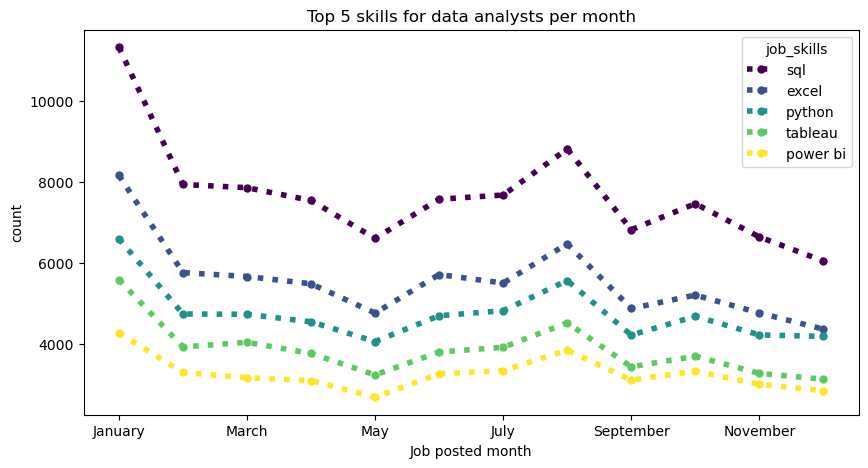

In [18]:
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month
df_DA_explode = df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index= 'job_posted_month_no', columns= 'job_skills', aggfunc= 'size', fill_value= 0)
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()

df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending= False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x : pd.to_datetime(x, format= '%m').strftime('%B'))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns= 'job_posted_month_no')


df_DA_pivot.iloc[:, :5].plot(
    kind= 'line',
    linewidth= 4,
    linestyle= ':',
    colormap= 'viridis',
    marker= 'o',
    markersize= 5,
    figsize= (10, 5)
)
plt.xlabel('Job posted month')
plt.title('Top 5 skills for data analysts per month')
plt.ylabel('count')
plt.show()

# Customizing our Scatter plot from 15_Scatter_Plot.ipynb

In [21]:
df_exploded = df_DA.explode('job_skills')

skill_stats =df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary =('salary_year_avg', 'median')
)

skill_count = 20
skill_stats = skill_stats.sort_values('skill_count', ascending = False).head(skill_count)

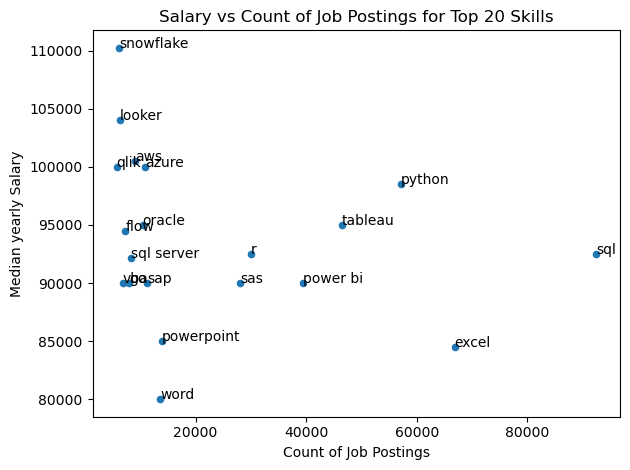

In [27]:
skill_stats.plot(kind = 'scatter', x = 'skill_count', y = 'median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median yearly Salary')
plt.title(f'Salary vs Count of Job Postings for Top {skill_count} Skills')
for i, text in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], text)
plt.tight_layout()
plt.show()

In [24]:
!pip install adjustText
from adjustText import adjust_text

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.6 MB 9.6 MB/s eta 0:00:04
   -- ------------------------------------- 2.4/36.6 MB 6.7 MB/s eta 0:00:06
   --- ------------------------------------ 3.4/36.6 MB 5.6 MB/s eta 0:00:06
   ---- ----------------------------------- 4.2/36.6 MB 5.7 MB/s eta 0:00:06
   ------ --------------------------------- 5.5/36.6 MB 5.6 MB/s eta 0:00:06
   ------- -------------------------------- 6.6/36.6 MB 5.4 MB/s eta 0:00:06
   -------- ------------------------------- 7.6/36.6 MB 5.2 MB/s eta 0:00:06
   --------- ------------------------------ 8.4/36.6 MB 5.1 MB/s eta 0:00:06
   ---------- ----------------------------- 9.4/36.6 MB 5.1 MB/s eta 0:00:06
   ----------- ---------------------------- 10.5/36.6 MB 5.1 MB/s eta 0:00:06
   ------------ --------------------------- 11.5/36.6 MB 5.0 MB/s eta 0:00:05
   -------------- ------------------------- 12.8/36.6 MB 5.1 MB/s eta 0:00:05
   

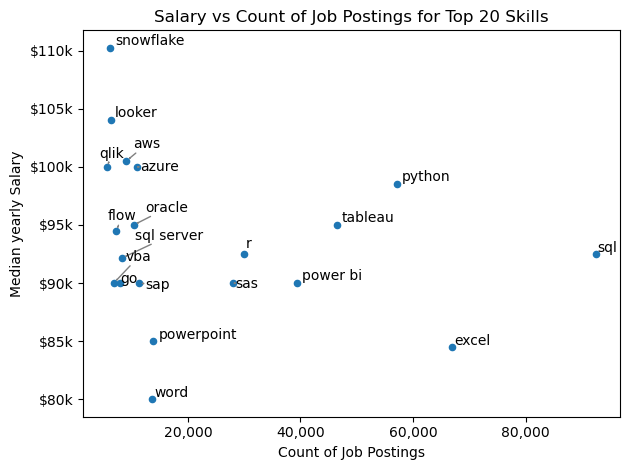

In [34]:
from adjustText import adjust_text

skill_stats.plot(kind = 'scatter', x = 'skill_count', y = 'median_salary')

texts = []
for i, text in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], text))

adjust_text(texts, arrowprops= dict(arrowstyle= '->', color= 'gray', lw= 1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'{int(x):,}')
)

plt.xlabel('Count of Job Postings')
plt.ylabel('Median yearly Salary')
plt.title(f'Salary vs Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()